# Capstone Three Notebook: Preprocessing, Visualization, and Modeling

This notebook follows Capstone Three directions for **preprocessing/training data development** (dummy variables/encoding, standardization, train-test split) and builds 2–3 models with evaluation.

**Dataset:** Diabetes 130-US hospitals (1999–2008) readmission prediction.


## 0. Setup

In [12]:
import os
import warnings

# Disable Python warnings globally
warnings.simplefilter("ignore")

# Also silence warnings at the environment level (Jupyter-safe)
os.environ["PYTHONWARNINGS"] = "ignore"

In [3]:

import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import joblib



## 1. Download + Load Data (from URL)
Downloads the dataset zip from UCI (if needed), extracts it, and loads `diabetic_data.csv`.


In [4]:

UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"

DATA_DIR = Path("data/diabetes_readmission")
DATA_DIR.mkdir(parents=True, exist_ok=True)

zip_path = DATA_DIR / "diabetes_130_us_hospitals.zip"
csv_path = DATA_DIR / "diabetic_data.csv"

def download_and_extract():
    if csv_path.exists():
        print("Found:", csv_path)
        return

    if not zip_path.exists():
        print("Downloading zip...")
        urllib.request.urlretrieve(UCI_ZIP_URL, str(zip_path))
        print("Downloaded:", zip_path)
    else:
        print("Found zip:", zip_path)

    print("Extracting...")
    with zipfile.ZipFile(str(zip_path), "r") as z:
        z.extractall(str(DATA_DIR))
    print("Done. Extracted to:", DATA_DIR)

download_and_extract()

df = pd.read_csv(str(csv_path))
print("Shape:", df.shape)
df.head(20)


Found: data/diabetes_readmission/diabetic_data.csv
Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Target Definition
Create a binary target: `readmitted_30d = 1` if `<30`, else `0`.


In [5]:

df = df.copy()
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)

print(df["readmitted"].value_counts())
print(df["readmitted_30d"].value_counts())


NO     54864
>30    35545
<30    11357
Name: readmitted, dtype: int64
0    90409
1    11357
Name: readmitted_30d, dtype: int64


## 3. Quick EDA & Visualization

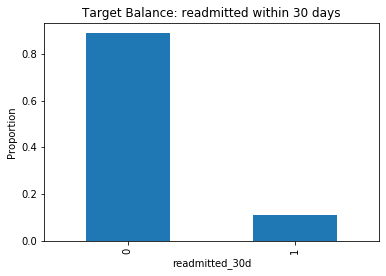

In [6]:

ax = df["readmitted_30d"].value_counts(normalize=True).sort_index().plot(kind="bar")
ax.set_title("Target Balance: readmitted within 30 days")
ax.set_xlabel("readmitted_30d")
ax.set_ylabel("Proportion")
plt.show()


In [7]:

missing_token = "?"
missing_counts = (df == missing_token).sum().sort_values(ascending=False)
missing_counts.head(15)


weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
encounter_id             0
tolazamide               0
glyburide                0
tolbutamide              0
pioglitazone             0
rosiglitazone            0
acarbose                 0
miglitol                 0
dtype: int64

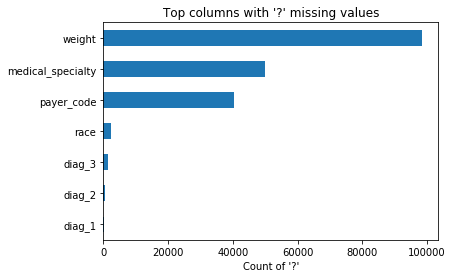

In [8]:

top_missing = missing_counts[missing_counts > 0].head(15)
ax = top_missing.sort_values().plot(kind="barh")
ax.set_title("Top columns with '?' missing values")
ax.set_xlabel("Count of '?'")
plt.show()


## 4. Minimal Feature Selection

In [9]:

drop_cols = ["encounter_id", "patient_nbr", "readmitted"]
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

y = df_model["readmitted_30d"].astype(int)
X = df_model.drop(columns=["readmitted_30d"])

print("X shape:", X.shape, "Positive rate:", y.mean())
X.head()


X shape: (101766, 47) Positive rate: 0.11159915885462728


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),?,1,1,7,3,?,?,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),?,1,1,7,2,?,?,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),?,1,1,7,1,?,?,...,No,No,Steady,No,No,No,No,No,Ch,Yes


## 5. Preprocessing Pipeline 
- `?` → NaN
- Imputation
- One-hot encoding
- Standard scaling (numeric)
- Stratified train/test split


In [10]:

X = X.replace("?", np.nan)

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", len(cat_cols), "Numeric:", len(num_cols))


Categorical: 36 Numeric: 11


In [13]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (81412, 47) Test: (20354, 47)


## 6. Modeling plus Evaluation

In [14]:

def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, [0, 1])
    plt.yticks(tick_marks, [0, 1])
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

def evaluate_binary(model, X_test, y_test, title="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    print("=" * 80)
    print(title)
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred, digits=3))

    cm = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix(cm, title="Confusion Matrix: " + title)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve: " + title)
    plt.show()

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve: " + title)
    plt.show()


Logistic Regression
ROC-AUC: 0.6439707914673891
              precision    recall  f1-score   support

           0      0.920     0.655     0.765     18083
           1      0.166     0.548     0.255      2271

    accuracy                          0.643     20354
   macro avg      0.543     0.601     0.510     20354
weighted avg      0.836     0.643     0.708     20354



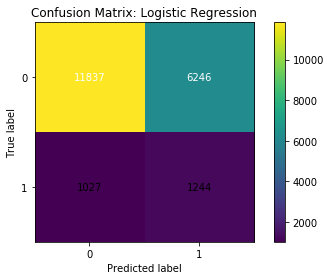

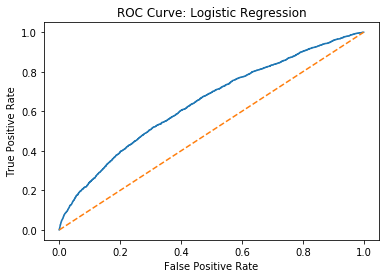

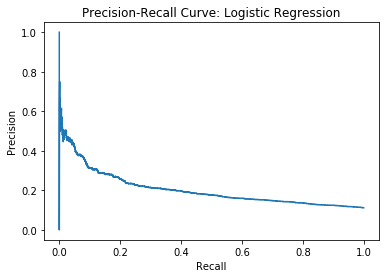

In [15]:

log_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
log_reg.fit(X_train, y_train)
evaluate_binary(log_reg, X_test, y_test, title="Logistic Regression")


Random Forest
ROC-AUC: 0.6630491189009005
              precision    recall  f1-score   support

           0      0.889     1.000     0.941     18083
           1      0.750     0.005     0.010      2271

    accuracy                          0.889     20354
   macro avg      0.819     0.503     0.476     20354
weighted avg      0.873     0.889     0.837     20354



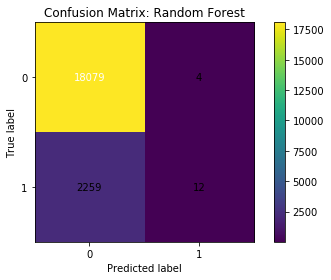

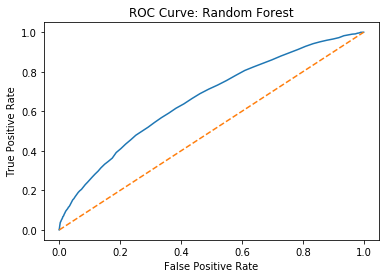

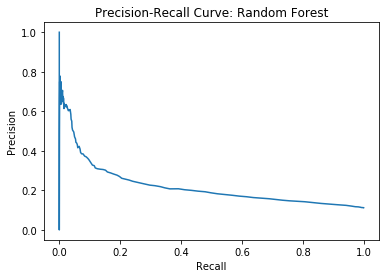

In [16]:

rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])
rf.fit(X_train, y_train)
evaluate_binary(rf, X_test, y_test, title="Random Forest")


Gradient Boosting (sklearn)
ROC-AUC: 0.6786130848816333
              precision    recall  f1-score   support

           0      0.889     0.999     0.941     18083
           1      0.486     0.007     0.015      2271

    accuracy                          0.888     20354
   macro avg      0.687     0.503     0.478     20354
weighted avg      0.844     0.888     0.838     20354



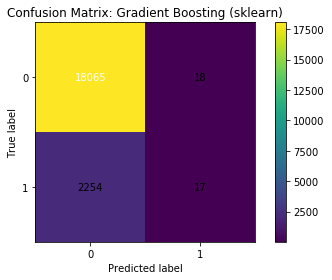

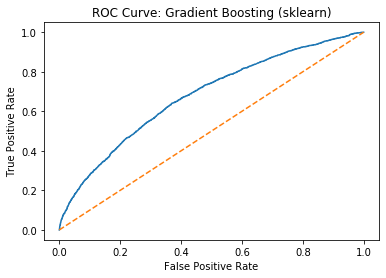

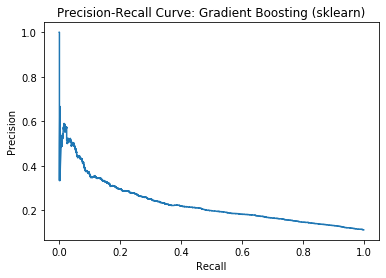

In [17]:

gb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=42))
])
gb.fit(X_train, y_train)
evaluate_binary(gb, X_test, y_test, title="Gradient Boosting (sklearn)")


## 7. Select Final Model

In [18]:

final_model = gb  # change to log_reg or rf based on your evaluation
print("Final model selected:", final_model.named_steps["model"].__class__.__name__)
joblib.dump(final_model, "final_readmission_model.joblib")

Final model selected: GradientBoostingClassifier


['final_readmission_model.joblib']

## 8. Summary
The initial dataset contained over 100,000 hospital encounters with mixed data types, including numeric variables, categorical variables, and missing values represented as "?". The target variable (readmitted) originally had three categories (<30, >30, NO), which was converted into a binary classification problem predicting 30-day readmission.
Data preprocessing included:Replacing "?" with NaN, Imputing missing values (median for numeric, most frequent for categorical), One-hot encoding categorical variables to create dummy features, Standardizing numeric features using StandardScaler, Performing a stratified train/test split to preserve class balance
Three models (Logistic Regression, Random Forest, and Gradient Boosting) were trained and evaluated using ROC-AUC, classification reports, confusion matrices, and ROC/PR curves. The best-performing model was selected as the final model.
